# Surface Velocities

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
import pandas as pd
import numpy as np
from importlib import reload
import cartopy.crs as ccrs
import cmocean.cm as cmo
import gsw
import scipy.ndimage as filter
import scipy.interpolate as interpolate

## Drifter Velocities

In [2]:
drift = xr.open_dataset('/swot/SUM05/amf2288/drifters.nc').rename({'longitude':'LON','latitude':'LAT'})
ds_pbar_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_flux.nc')

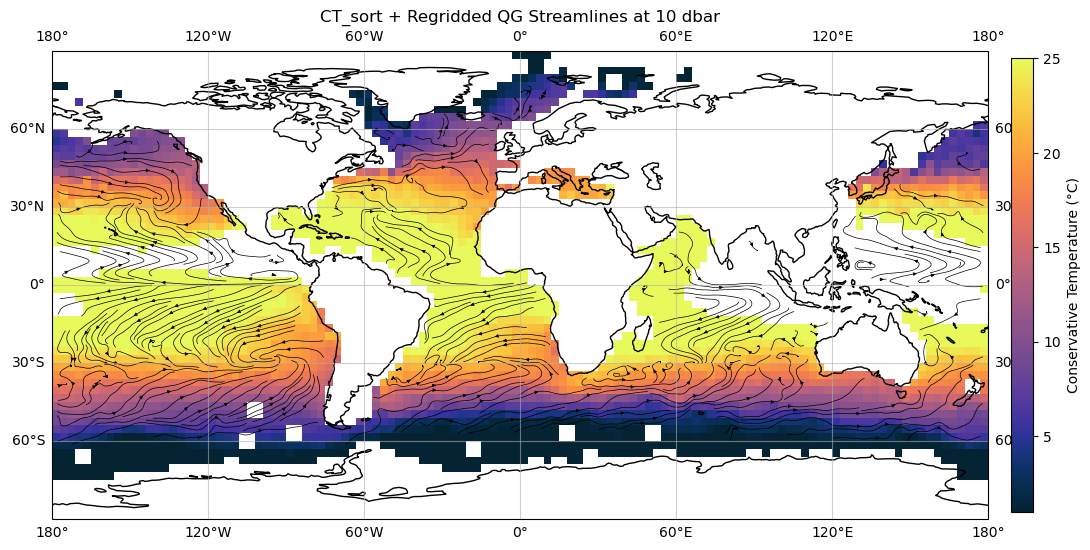

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean.cm as cmo

# ---------------------------------------------------------
# 1. Extract ds_pbar_grid coordinates (target grid)
# ---------------------------------------------------------
lon_p = ds_pbar_grid.LON.values      # (lon_p,)
lat_p = ds_pbar_grid.LAT.values      # (lat_p,)
Lon2d_p, Lat2d_p = np.meshgrid(lon_p, lat_p)

# ---------------------------------------------------------
# 2. Regrid drifter velocities onto ds_pbar_grid grid
# ---------------------------------------------------------
U_on_p = drift.U.interp(LON=lon_p, LAT=lat_p)
V_on_p = drift.V.interp(LON=lon_p, LAT=lat_p)

# Convert to numpy arrays in (lat, lon) order
U = U_on_p.values.T
V = V_on_p.values.T

# Optional subsampling for streamlines
step = 1
U_s = U[::step, ::step]
V_s = V[::step, ::step]
lon_s = lon_p[::step]
lat_s = lat_p[::step]
Lon2d_s, Lat2d_s = np.meshgrid(lon_s, lat_s)

# ---------------------------------------------------------
# 3. Extract CT_sort on the ds_pbar_grid grid
# ---------------------------------------------------------
depth = 10  # choose your pressure level
CT_native = ds_pbar_grid.CT_sort.sel(PRESSURE_mean=depth, method='nearest')

# Regrid CT_sort onto ds_pbar_grid
CT_on_p = CT_native.interp(LON=lon_p, LAT=lat_p)
CT = CT_on_p.values.T   # (lat, lon)

# ---------------------------------------------------------
# 4. Plot CT_sort + streamlines
# ---------------------------------------------------------
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': proj})

# Background scalar field
pcm = ax.pcolormesh(
    lon_p, lat_p, CT,
    cmap=cmo.thermal,
    vmin=1, vmax=25,
    transform=proj
)

cbar = plt.colorbar(pcm, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Conservative Temperature (°C)")

# Streamlines
strm = ax.streamplot(
    Lon2d_s, Lat2d_s,
    U_s, V_s,
    transform=proj,
    density=(8, 4),   # tuned for coarse grid
    color='k',
    linewidth=0.5,
    arrowsize=0.5
)

# Map decoration
ax.coastlines()
ax.gridlines(draw_labels=True, alpha=0.6)
ax.set_title(f"CT_sort + Regridded QG Streamlines at {depth} dbar")

plt.tight_layout()
plt.show()